# GestDeck - Cuaderno 02: Arquitectura LSTM, Entrenamiento y Evaluación

Este cuaderno abarca el diseño formal de la red neuronal, su entrenamiento y la evaluación del rendimiento. A partir de los tensores limpios generados en el cuaderno anterior, construiremos una **Recurrente Profunda (Deep LSTM)**.

## 1. Justificación de la Arquitectura Seleccionada

Se ha seleccionado una red **Long Short-Term Memory (LSTM)** porque la naturaleza de los gestos de las manos es **secuencial** a través del tiempo. Un gesto no es una imagen estática, es una evolución de posiciones a lo largo de 15 frames. Las LSTMs pueden "recordar" secuencias a largo plazo y evitar el desvanecimiento de gradientes clásico de las RNN simples.

### Especificación Formal de Entradas y Salidas
- **Tensor de Entrada ($X$)**: `(None, 15, 42)`
  - `None`: Tamaño dinámico del batch.
  - `15`: Timesteps (Resolución temporal de 15 frames por video).
  - `42`: Features (21 landmarks extraídos $\times$ 2 coordenadas espaciales $X, Y$).
- **Profundidad y Normalización**: `float32`, con rango estático dinámico pre-normalizado $[0.0, 1.0]$ heredado del bounding box interno de MediaPipe.
- **Tensor de Salida ($Y$)**: `(None, 9)`
  - Array probabilístico distribuido entre las 9 clases (Softmax).

### Diagrama de Flujo de Datos

```mermaid
graph TD
    A["Video Crudo (.mp4)"] -->|MediaPipe Tasks| B("Tensor 3D (Muestras, 15, 42)")
    B -->|Masking| C["Ignorar frames con ceros"]
    C -->|LSTM 64 units| D["Extracción Temporal Baja"]
    D -->|LSTM 64 units| E["Extracción Temporal Alta"]
    E -->|LSTM 32 units| F["Refinamiento"]
    F -->|Batch Normalization| G["Estabilización de Gradientes"]
    G -->|Dense 32 + ReLU| H["Razonamiento Lógico"]
    H -->|Dense 9 + Softmax| I(("Predicción de Gesto"))
```

In [36]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# TensorFlow / Keras para Arquitectura Profunda
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Evaluación
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

# Directorios
FINAL_DATA_DIR = "../dataset/final"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

## 2. Carga de los Datos Estratificados
Cargamos los datos que fueron divididos y aumentados meticulosamente en el Cuaderno 01.

In [38]:
# Cargar tensores
X_train = np.load(os.path.join(FINAL_DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(FINAL_DATA_DIR, "y_train.npy"))

X_val = np.load(os.path.join(FINAL_DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(FINAL_DATA_DIR, "y_val.npy"))

X_test = np.load(os.path.join(FINAL_DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(FINAL_DATA_DIR, "y_test.npy"))

with open(os.path.join(FINAL_DATA_DIR, "labels.json"), "r") as f:
    classes = json.load(f)

print(f"Volumen Train: {X_train.shape} | Labels: {y_train.shape}")
print(f"Volumen Val:   {X_val.shape} | Labels: {y_val.shape}")
print(f"Volumen Test:  {X_test.shape} | Labels: {y_test.shape}")

Volumen Train: (2095, 15, 42) | Labels: (2095,)
Volumen Val:   (53, 15, 42) | Labels: (53,)
Volumen Test:  (53, 15, 42) | Labels: (53,)


## 2.5. Validacion Cruzada Estratificada (K-Fold)

Con un dataset pequeno, un unico split 80/10/10 puede dar una metrica optimista por azar. La validacion cruzada de 5 pliegues entrena y evalua el modelo 5 veces con distintas particiones, entregando una estimacion mas robusta del rendimiento real.

> Esta celda puede tardar varios minutos. Los resultados indican si el modelo generaliza de forma consistente o si el 100% del test fue suerte del split.


In [67]:
from sklearn.model_selection import StratifiedKFold
from hashlib import md5
import json as _json

# Reconstruir X_clean desde los archivos procesados
processed_dir = "../dataset/processed"
with open(os.path.join(processed_dir, "dataset_index.json")) as _f:
    _idx = _json.load(_f)

X_cv_all, y_cv_all = [], []
for i, cls in enumerate(classes):
    if cls in _idx:
        _path = os.path.join(processed_dir, os.path.basename(_idx[cls]))
        if os.path.exists(_path):
            for sample in np.load(_path):
                if np.sum(np.all(sample == 0, axis=1)) <= 3:
                    X_cv_all.append(sample)
                    y_cv_all.append(i)

def _h(s): return md5(s.tobytes()).hexdigest()
_seen, X_cv, y_cv = set(), [], []
for s, l in zip(X_cv_all, y_cv_all):
    if _h(s) not in _seen:
        _seen.add(_h(s)); X_cv.append(s); y_cv.append(l)
X_cv, y_cv = np.array(X_cv), np.array(y_cv)
print(f"Datos para CV: {X_cv.shape}")

def build_model_cv():
    m = Sequential([
        Masking(mask_value=0.0, input_shape=(X_cv.shape[1], 42)),
        LSTM(64, return_sequences=True), Dropout(0.3),
        LSTM(64, return_sequences=True), Dropout(0.3),
        LSTM(32, return_sequences=False), Dropout(0.3),
        BatchNormalization(),
        Dense(32, activation="relu"),
        Dense(len(classes), activation="softmax")
    ])
    m.compile(optimizer=Adam(0.001, clipnorm=1.0),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for fold, (tr_idx, val_idx) in enumerate(kfold.split(X_cv, y_cv)):
    fold_model = build_model_cv()
    fold_model.fit(
        X_cv[tr_idx], y_cv[tr_idx],
        epochs=60, batch_size=16,
        validation_data=(X_cv[val_idx], y_cv[val_idx]),
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=0
    )
    _, acc = fold_model.evaluate(X_cv[val_idx], y_cv[val_idx], verbose=0)
    cv_scores.append(acc)
    print(f"  Fold {fold+1}/5: accuracy = {acc:.4f}")

print(f"\nCV Accuracy: {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}")
print(f"Rango: [{min(cv_scores):.4f}, {max(cv_scores):.4f}]")


Datos para CV: (525, 15, 42)


c:\Users\Usuario\Downloads\gestdeck-prueba\.venv\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 1/5: accuracy = 0.9143
  Fold 2/5: accuracy = 0.8095
  Fold 3/5: accuracy = 0.8857
  Fold 4/5: accuracy = 0.8000
  Fold 5/5: accuracy = 0.8667

CV Accuracy: 0.8552 +/- 0.0440
Rango: [0.8000, 0.9143]


## 3. Construcción del Modelo Profundo (Deep Model)

Implementamos 3 capas LSTMs. Añadimos **Batch Normalization** tras la última etapa recurrente para centrar las activaciones, estabilizar los pesos y facilitar la convergencia rápida del optimizador Adam.

In [99]:
SEQ_LEN = X_train.shape[1]

model = Sequential([
    Masking(mask_value=0.0, input_shape=(SEQ_LEN, 42)),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    BatchNormalization(),
    Dense(32, activation="relu"),
    Dense(len(classes), activation="softmax")
])

# clipnorm=1.0 previene gradient explosion (el pico en val_loss)
model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_35 (Masking)            │ (None, 15, 42)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_105 (LSTM)                 │ (None, 15, 64)         │        27,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_105 (Dropout)           │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_106 (LSTM)                 │ (None, 15, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_106 (Dropout)           │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_107 (LSTM)                 │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_107 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,313 (290.29 KB)

 Trainable params: 74,249 (290.04 KB)

 Non-trainable params: 64 (256.00 B)

## 4. Entrenamiento (Training Pipeline)
Ejecutamos el entrenamiento con un mínimo formal de **50 épocas** y un `EarlyStopping` para prevenir gastar cómputo en vano si la red deja de mejorar. Guardaremos el mejor modelo en `.keras`.

In [100]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

MODEL_PATH = os.path.join(MODELS_DIR, "gestures_model.keras")

callbacks = [
    # EarlyStopping en val_loss: continua y estable con val sets pequenos
    # ModelCheckpoint en val_accuracy: guarda el modelo con mejor clasificacion
    EarlyStopping(monitor="val_loss", patience=15,
                  restore_best_weights=True, mode="min"),
    ModelCheckpoint(MODEL_PATH, monitor="val_accuracy",
                    save_best_only=True, mode="max"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                      min_lr=1e-5, verbose=1),
]

print("Iniciando Entrenamiento de la LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
print("Entrenamiento finalizado y modelo guardado!")


Iniciando Entrenamiento de la LSTM...
Epoch 1/80
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2282 - loss: 2.0207 - val_accuracy: 0.4528 - val_loss: 1.8172 - learning_rate: 0.0010
Epoch 2/80
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4897 - loss: 1.3266 - val_accuracy: 0.6981 - val_loss: 1.0861 - learning_rate: 0.0010
Epoch 3/80
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5967 - loss: 1.0318 - val_accuracy: 0.7170 - val_loss: 0.9107 - learning_rate: 0.0010
Epoch 4/80
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6640 - loss: 0.8981 - val_accuracy: 0.5472 - val_loss: 1.2953 - learning_rate: 0.0010
Epoch 5/80
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6792 - loss: 0.8397 - val_accuracy: 0.7925 - val_loss: 0.6465 - learning_rate: 0.0010
Epoch 6/80
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7289 - loss: 0.7274 - val_accuracy: 0.6604 - val_loss: 0.8619 - learning_rate: 0.0010
Epoch 7/80
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/s

## 5. Evaluación de Métricas y Profilaje (Profiling)
Visualización de la convergencia y métricas puras usando el 10% del dataset que fue reservado celosamente (`X_test`).

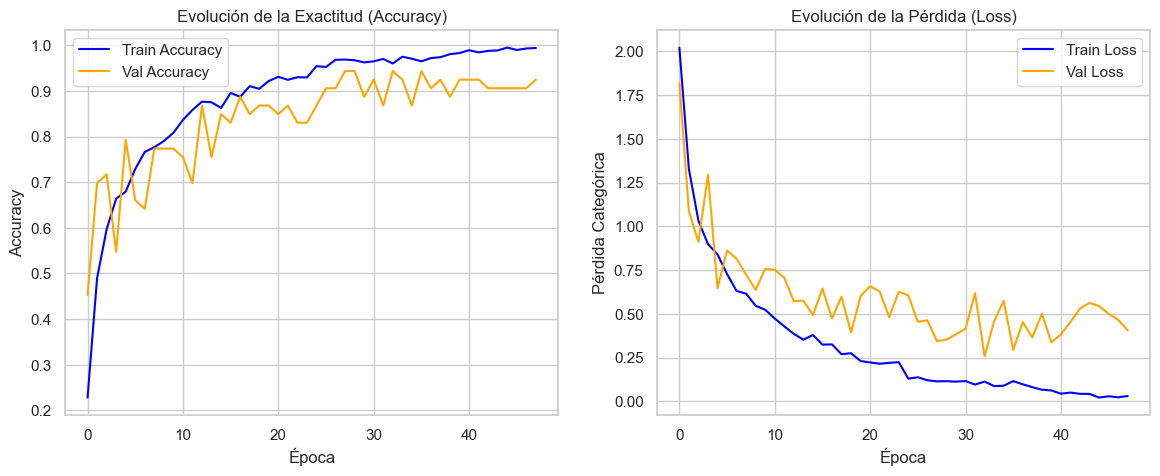

In [101]:
# 5.1 Curvas de Convergencia (Learning Curves)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida Categórica')
plt.legend()

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step

=== REPORTE DE CLASIFICACIÓN (Test Set) ===
               precision    recall  f1-score   support

     ANTERIOR       1.00      1.00      1.00         6
       EMPUJE       1.00      1.00      1.00         4
       INDICE       1.00      1.00      1.00         6
PALMA_ABIERTA       1.00      0.83      0.91         6
        PAUSA       0.83      1.00      0.91         5
     PELLIZCO       1.00      0.71      0.83         7
 PELLIZCO_INV       0.70      1.00      0.82         7
 PUNO_CERRADO       1.00      0.86      0.92         7
    SIGUIENTE       1.00      1.00      1.00         5

     accuracy                           0.92        53
    macro avg       0.95      0.93      0.93        53
 weighted avg       0.94      0.92      0.93        53



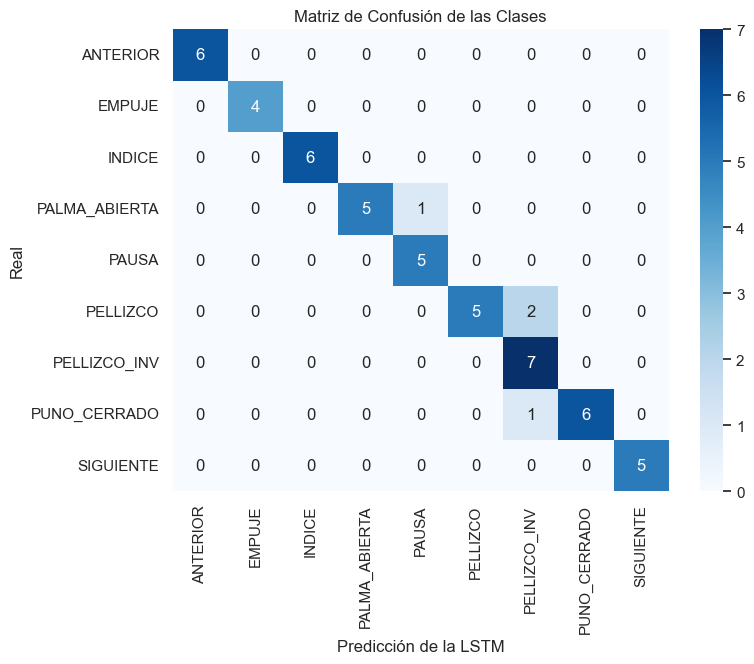

In [102]:
# 5.2 Predicciones sobre el Conjunto de Test (NUNCA VISTO POR EL MODELO)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 5.3 Classification Report (Precision, Recall, F1)
print("\n=== REPORTE DE CLASIFICACIÓN (Test Set) ===")
print(classification_report(y_test, y_pred, labels=np.arange(len(classes)), target_names=classes, zero_division=0))

# 5.4 Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión de las Clases')
plt.ylabel('Real')
plt.xlabel('Predicción de la LSTM')
plt.show()

In [103]:
# 5.5 Profilaje: Tamaño y Velocidad
model_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)

# Medimos la velocidad realizando 100 inferencias sobre una muestra dummy
dummy_input = np.zeros((1, X_train.shape[1], 42))
start_time = time.time()
for _ in range(100):
    _ = model.predict(dummy_input, verbose=0)
end_time = time.time()

inference_speed_ms = ((end_time - start_time) / 100) * 1000

print("=== PROFILAJE DEL MODELO ===")
print(f"Peso físico del modelo: {model_size_mb:.2f} MB")
print(f"Velocidad de Inferencia: {inference_speed_ms:.2f} milisegundos por predicción")

=== PROFILAJE DEL MODELO ===
Peso físico del modelo: 0.91 MB
Velocidad de Inferencia: 46.46 milisegundos por predicción


## 6. Prueba en Vivo (Inferencia del Mundo Real)

Con el modelo ya entrenado y verificado, esta celda te permite probar la red pasándole **cualquier video real**. 
Internamente extraerá los puntos con MediaPipe, los convertirá en un tensor `(1, 15, 42)`, y le pedirá a tu LSTM que dictamine de qué gesto se trata.

In [118]:
import urllib.request, cv2
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import mediapipe as mp

CONFIDENCE_THRESHOLD = 0.70

# Detector inicializado una sola vez (lazy) para evitar overhead por llamada
_mp_detector = None

def _get_detector():
    global _mp_detector
    if _mp_detector is None:
        _mp = "hand_landmarker.task"
        if not os.path.exists(_mp):
            urllib.request.urlretrieve(
                "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
                _mp
            )
        _mp_detector = vision.HandLandmarker.create_from_options(
            vision.HandLandmarkerOptions(
                base_options=python.BaseOptions(model_asset_path=_mp),
                num_hands=1,
                min_hand_detection_confidence=0.3,
                min_hand_presence_confidence=0.3,
                min_tracking_confidence=0.3
            )
        )
    return _mp_detector

def predict_video_gesture(video_path):
    if not os.path.exists(video_path):
        print(f"[Error] No se encontro: {video_path}"); return

    seq_len  = model.input_shape[1]
    detector = _get_detector()

    cap = cv2.VideoCapture(video_path)
    raw_detections, frame_idx = [], 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                          data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        res = detector.detect(mp_img)
        if res.hand_landmarks:
            feats = []
            for lm in res.hand_landmarks[0]: feats.extend([lm.x, lm.y])
            raw_detections.append((frame_idx, np.array(feats)))
        frame_idx += 1
    cap.release()

    if len(raw_detections) < 2:
        print("No se detectaron suficientes frames con mano."); return

    # Interpolacion (mismo pipeline que entrenamiento)
    det_idx = np.array([f[0] for f in raw_detections])
    det_vec = np.array([f[1] for f in raw_detections])
    all_idx = np.arange(det_idx[0], det_idx[-1] + 1)
    interp  = np.zeros((len(all_idx), 42))
    for d in range(42):
        interp[:, d] = np.interp(all_idx, det_idx, det_vec[:, d])

    frames = interp[:seq_len] if len(interp) >= seq_len else \
             np.vstack([interp, np.zeros((seq_len - len(interp), 42))])

    probs      = model.predict(np.expand_dims(frames, axis=0), verbose=0)[0]
    pred_idx   = np.argmax(probs)
    confidence = probs[pred_idx] * 100

    print("\n" + "="*45)
    print(f"Video : {os.path.basename(video_path)}")
    if confidence < CONFIDENCE_THRESHOLD * 100:
        print(f"Gesto no reconocido  (confianza {confidence:.1f}% < umbral {CONFIDENCE_THRESHOLD*100:.0f}%)")
    else:
        print(f"Gesto   : {classes[pred_idx]}")
        print(f"Confianza: {confidence:.2f}%")
        top3 = np.argsort(probs)[::-1][:3]
        print("Top-3 : " + ", ".join(
            f"{classes[i]} ({probs[i]*100:.1f}%)" for i in top3))
    print("="*45)

# EJEMPLO:
# predict_video_gesture("ruta/a/tu/video.mp4")
predict_video_gesture("C:/Users/Usuario/Downloads/gestdeck-prueba/prueba09.mp4")



Video : prueba09.mp4
Gesto   : PELLIZCO
Confianza: 100.00%
Top-3 : PELLIZCO (100.0%), INDICE (0.0%), PELLIZCO_INV (0.0%)
